In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [2]:
image_path = "../output_videos/cropped_image.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

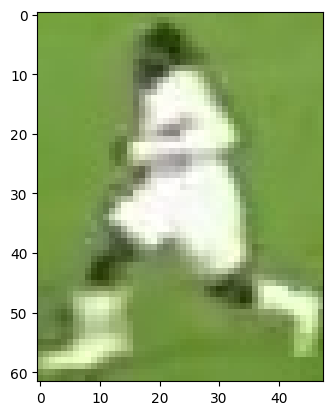

In [3]:
plt.imshow(image)
plt.show()

# Take the top half of the image

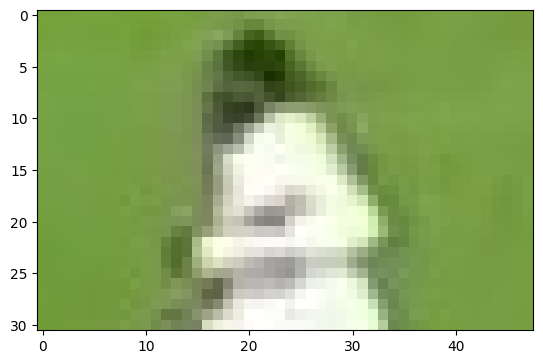

In [4]:
top_half_image = image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)
plt.show()

# Cluster the image into two clusters


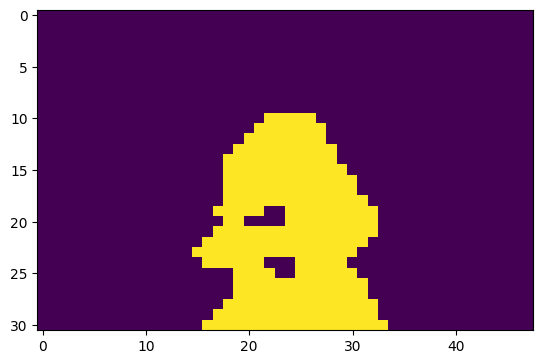

In [11]:
# Reshape the image into 2d array
image_2d = top_half_image.reshape(-1, 3)

# perform k-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# get the cluster labels
labels = kmeans.labels_

# reshape the labels into the original image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

# Display the clustered image
plt.imshow(clustered_image)
plt.show()

### Intuition: 
In order to figure out the proper segmentation (which class is for the shirt color and which is the background), we will take the corners of the images and take the majority amount of classes that shows up on the corners. Because normally the corners would most likely represent the background, we find the class that shows up as majority and set that class as the background

In [12]:
corner_clusters = [clustered_image[0,0], clustered_image[0, -1], clustered_image[-1, -1], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

0


In [13]:
player_cluster = 1 - non_player_cluster
print(player_cluster)

1


In [14]:
# Take the cluster center to get the color of the shirt
kmeans.cluster_centers_[player_cluster]

array([227.38931298, 232.36259542, 214.42748092])